In [1]:
!pip install koreanize-matplotlib sdv catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.9/185.9 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 130.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.4/198.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 9.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import warnings
from dateutil.relativedelta import relativedelta
from bisect import bisect_left, bisect_right
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from sklearn.ensemble import IsolationForest
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive/')
path = '/content/drive/MyDrive/거래_이상탐지_프로젝트/data'

Mounted at /content/drive/


In [4]:
train_df = pd.read_csv(path+"/fraudTrain.csv")
test_df = pd.read_csv(path+"/fraudTest.csv")

In [5]:
def calculate_age(born, trans_date):
    return relativedelta(trans_date, born).years

def count_past_days_fast(df, days):
    results = []
    grouped = df.groupby('cc_num')

    for card, group in grouped:
        times = group['trans_date_trans_time'].tolist()
        counts = []
        for i, t in enumerate(times):
            start_time = t - pd.Timedelta(days=days)
            # 왼쪽 경계 (start_time 이상)
            left_idx = bisect_left(times, start_time)
            # 오른쪽 경계는 현재 거래 바로 전(i번째 거래 제외)
            right_idx = i
            counts.append(right_idx - left_idx)
        results.extend(counts)
    return results

def preprocess_data(df: pd.DataFrame,
                    hour: str = 'sincos',
                    high_risk_period: bool = False,
                    age_group: bool = False
                    ) -> pd.DataFrame:
    '''
    Arg)
    df : 데이터프레임
    hour : 시간 전처리방법 (sincos : sin/cos 변환 , is_night : 'is_night' 칼럼 사용)
    high_risk_period : high_risk_period 사용여부 (Default : False)
    age_group : age_group 사용여부 (Default : False)
    '''

    # 원본 데이터프레임 복사
    df_p = df.copy()

    drop_cols = ['Unnamed: 0', 'unix_time', 'trans_num', 'first', 'last', 'merchant', 'street', 'merch_lat', 'merch_long', 'city_pop', 'lat', 'long', 'zip']
    df_p = df_p.drop(columns=drop_cols)

    # 로그 변환
    df_p['amt_log'] = np.log1p(df_p['amt'])

    # 표준화
    scaler = StandardScaler()
    df_p['amt_log_std'] = scaler.fit_transform(df_p[['amt_log']])

    # datetime 변환
    df_p['datetime'] = pd.to_datetime(df_p['trans_date_trans_time'])

    # 시(hour) 추출 (0~23)
    df_p['hour'] = df_p['datetime'].dt.hour

    # 요일 추출: Monday=0, Sunday=6
    df_p['day_of_week'] = df_p['datetime'].dt.dayofweek

    # 월 추출: 1월=1, 12월=12
    df_p['month'] = df_p['datetime'].dt.month

    # Hour : SinCos변환 or Is_night 사용
    if hour == 'sincos':
        df_p['trans_hour_sin'] = np.sin(2 * np.pi * df_p['hour'] / 24)
        df_p['trans_hour_cos'] = np.cos(2 * np.pi * df_p['hour'] / 24)
    elif hour == 'is_night':
        df_p['is_night'] = df_p['hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)


    # higt_rist_period 사용여부
    if high_risk_period:
        # 금(4), 목(3), 수(2) + 심야 시간대(0~4, 21~23)
        high_risk_days = [2, 3, 4]  # 수, 목, 금
        high_risk_hours = list(range(0, 5)) + [21, 22, 23]

        df_p['is_high_risk_period'] = (
            df_p['day_of_week'].isin(high_risk_days) & df_p['hour'].isin(high_risk_hours)
        ).astype(int)

    df_p['trans_date_trans_time'] = pd.to_datetime(df_p['trans_date_trans_time'])
    df_p = df_p.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)

    df_p['cnt_1d'] = count_past_days_fast(df_p, 1)
    df_p['cnt_7d'] = count_past_days_fast(df_p, 7)
    df_p['cnt_30d'] = count_past_days_fast(df_p, 30)

    df_p['next_trans_time'] = df_p.groupby('cc_num')['trans_date_trans_time'].shift(-1)
    df_p['time_since_last_trans'] = (df_p['trans_date_trans_time'] - df_p.groupby('cc_num')['trans_date_trans_time'].shift(1)).dt.total_seconds()

    # 또는 마지막 거래 이후 경과 시간(다음 거래까지 시간 간격)
    df_p['time_until_next_trans'] = (df_p['next_trans_time'] - df_p['trans_date_trans_time']).dt.total_seconds()

    # 결측치 처리 (time_since_last_trans 첫 거래는 NaN, 0으로 채우거나 다른 방식)
    df_p[['time_since_last_trans', 'time_until_next_trans']] = df_p[['time_since_last_trans', 'time_until_next_trans']].fillna(0)


    df_p['dob'] = pd.to_datetime(df_p['dob'])

    df_p['age'] = df_p.apply(lambda x: calculate_age(x['dob'], x['trans_date_trans_time']), axis=1)

    if age_group:
        df_p['age_group'] = (df_p['age'] // 10) * 10
        df_p = df_p.drop(columns=['age'])


    # Job 칼럼 Target Encoding + Smoothing ( 아직 없음 )

    df_p['city_state'] = df_p['city'] + ', ' + df_p['state']

    # 최종 Drop
    drop_cols = ['trans_date_trans_time', 'dob', 'next_trans_time', 'cc_num', 'datetime', 'time_until_next_trans', 'city', 'state', 'amt', 'amt_log', 'hour']
    df_p = df_p.drop(columns=drop_cols)

    return df_p

In [6]:
# K-Fold, 타겟 인코딩 스무딩 함수
def m_estimate_smoothing(mean, global_mean, count, m):
    """M-estimate 스무딩을 적용하여 평균을 계산합니다."""
    return (mean * count + global_mean * m) / (count + m)

def kfold_target_encoding(df, target_col, cat_cols, n_splits=5, m_param=10):
    """
    K-Fold 교차 검증 방식의 타겟 인코딩을 M-estimate 스무딩과 함께 적용합니다.
    주어진 cat_cols 리스트에 있는 모든 컬럼에 대해 OOF 인코딩을 적용하고,
    각 컬럼에 대한 Full 인코딩 맵과 전역 평균을 반환합니다.

    Args:
        df: 입력 데이터프레임 (훈련 데이터).
        target_col: 타겟 컬럼 이름 (예: 'is_fraud').
        cat_cols: 인코딩하고 값을 덮어쓸 범주형 컬럼 이름의 리스트.
        n_splits: K-Fold 분할 개수.
        m_param: M-estimate 스무딩 파라미터.
    Returns:
        tuple: (OOF 인코딩된 DataFrame, 각 컬럼별 Full 인코딩 맵과 전역 평균을 담은 딕셔너리)
    """
    df_processed = df.copy() # 원본 DataFrame을 직접 수정하지 않기 위해 복사본 사용
    global_mean = df_processed[target_col].mean() # 전체 타겟 변수의 평균 (모든 인코딩에 공통 사용)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # 각 범주형 컬럼별로 학습된 Full 인코딩 맵과 전역 평균을 저장할 딕셔너리
    all_learned_encoding_info = {}

    # cat_cols가 단일 문자열로 들어올 경우를 대비해 리스트로 변환 (안정성 강화)
    if not isinstance(cat_cols, list):
        cat_cols = [cat_cols]

    for cat_col in cat_cols: # 각 범주형 컬럼에 대해 반복 처리
        print(f"--- '{cat_col}' 컬럼 OOF 인코딩 진행 중 ---")
        temp_oof_encoded_values = np.empty(len(df_processed))
        temp_oof_encoded_values[:] = np.nan # 초기화

        for train_idx, valid_idx in kf.split(df_processed):
            train_fold = df_processed.iloc[train_idx]

            # 훈련 폴드에서 해당 cat_col의 평균 및 개수 집계
            agg = train_fold.groupby(cat_col)[target_col].agg(['mean', 'count']).reset_index()

            # M-estimate 스무딩 적용
            agg['smoothed'] = m_estimate_smoothing(agg['mean'], global_mean, agg['count'], m_param)
            mapping = dict(zip(agg[cat_col], agg['smoothed']))

            # 유효성 검사 폴드의 해당 cat_col 위치에 스무딩된 값을 매핑
            temp_oof_encoded_values[valid_idx] = df_processed.loc[valid_idx, cat_col].map(mapping).fillna(global_mean)

        # 모든 폴드에 대한 처리가 끝난 후, df_processed에 OOF 인코딩된 값을 덮어씁니다.
        df_processed[cat_col] = temp_oof_encoded_values

        # 현재 컬럼에 대한 Full 인코딩 맵 생성 (테스트 데이터 인코딩에 사용될 예정)
        full_agg = df.groupby(cat_col)[target_col].agg(['mean', 'count']).reset_index()
        full_agg['smoothed'] = m_estimate_smoothing(full_agg['mean'], global_mean, full_agg['count'], m_param)
        full_encoding_map = dict(zip(full_agg[cat_col], full_agg['smoothed']))

        # 각 컬럼의 맵과 전역 평균을 딕셔너리에 저장
        all_learned_encoding_info[cat_col] = {
            'map': full_encoding_map,
            'global_mean': global_mean # 각 컬럼별 전역 평균은 동일
        }

    return df_processed, all_learned_encoding_info # OOF 인코딩된 DF와 모든 Full 맵/전역 평균 정보 반환


def test_data_target_encoding(df, cat_cols, learned_encoding_info):
    """
    제공된 인코딩 맵과 전역 평균을 사용하여 테스트 데이터프레임의 여러 컬럼을 인코딩합니다.

    Args:
        df: 입력 데이터프레임 (테스트 데이터).
        cat_cols: 인코딩할 범주형 컬럼 이름의 리스트.
        learned_encoding_info: kfold_target_encoding에서 반환된 학습된 인코딩 정보를 담은 딕셔너리.
                               예: {'col1': {'map': map1, 'global_mean': gm1}, 'col2': {'map': map2, 'global_mean': gm2}}
    Returns:
        인코딩된 컬럼이 덮어씌워진 DataFrame.
    """
    df_processed = df.copy()

    # cat_cols가 단일 문자열로 들어올 경우를 대비해 리스트로 변환 (안정성 강화)
    if not isinstance(cat_cols, list):
        cat_cols = [cat_cols]

    for cat_col in cat_cols:
        if cat_col not in learned_encoding_info:
            print(f"경고: '{cat_col}' 컬럼에 대한 학습된 인코딩 정보가 없습니다. 해당 컬럼은 인코딩되지 않습니다.")
            continue

        encoding_map = learned_encoding_info[cat_col]['map']
        global_mean = learned_encoding_info[cat_col]['global_mean']

        # 인코딩 값 덮어쓰기: 맵에 없는 값은 해당 컬럼의 전역 평균으로 대체
        df_processed[cat_col] = df_processed[cat_col].map(encoding_map).fillna(global_mean)
        print(f"--- '{cat_col}' 컬럼 테스트 데이터 인코딩 완료 ---")

    return df_processed

베이스라인

In [7]:
X = train_df.drop('is_fraud', axis=1)
y = train_df['is_fraud']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = test_df.copy()
print("데이터 분할 완료")
print(f"학습: {df_train.shape}, 검증: {df_val.shape}, 테스트: {df_test.shape}\n" + "-"*50)

데이터 분할 완료
학습: (1037340, 23), 검증: (259335, 23), 테스트: (555719, 23)
--------------------------------------------------


In [12]:
print("1차 기본 전처리 시작...")
# preprocess_data 함수가 이미 정의되어 있다고 가정합니다.
train_temp = preprocess_data(df_train, high_risk_period=True, age_group=False)
val_temp = preprocess_data(df_val, high_risk_period=True, age_group=False)
test_temp = preprocess_data(df_test, high_risk_period=True, age_group=False)
print("-> 1차 기본 전처리 완료.")

1차 기본 전처리 시작...
-> 1차 기본 전처리 완료.


In [13]:
# 고차원성 변수 제거
high_cardinality_cols = ['job', 'city_state']

train_temp.drop(columns=high_cardinality_cols, errors='ignore', inplace=True)
val_temp.drop(columns=high_cardinality_cols, errors='ignore', inplace=True)
test_temp.drop(columns=high_cardinality_cols, errors='ignore', inplace=True)

In [14]:
print("\n[단계 2] 원핫 인코딩 시작...")
categorical_features = ['category', 'gender', 'day_of_week', 'is_high_risk_period']

# 학습, 검증, 테스트 데이터셋에 원핫 인코딩 적용
train_final = pd.get_dummies(train_temp, columns=categorical_features, dummy_na=False, drop_first=True)
val_final = pd.get_dummies(val_temp, columns=categorical_features, dummy_na=False, drop_first=True)
test_final = pd.get_dummies(test_temp, columns=categorical_features, dummy_na=False, drop_first=True)

# 학습, 검증, 테스트 데이터셋의 컬럼을 통일
train_cols = train_final.columns
val_final = val_final.reindex(columns=train_cols, fill_value=0)
test_final = test_final.reindex(columns=train_cols, fill_value=0)
print("-> 원핫 인코딩 완료.")


[단계 2] 원핫 인코딩 시작...
-> 원핫 인코딩 완료.


In [15]:
train_final

,is_fraud,amt_log_std,month,trans_hour_sin,trans_hour_cos,cnt_1d,cnt_7d,cnt_30d,time_since_last_trans,age,...,category_shopping_pos,category_travel,gender_M,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,is_high_risk_period_1
0,0,-1.101823,1,1.224647e-16,-1.000000,0,0,0,0.0,32,...,False,False,False,True,False,False,False,False,False,False
1,0,0.352769,1,8.660254e-01,-0.500000,1,1,1,71862.0,32,...,False,False,False,False,True,False,False,False,False,False
2,0,0.687811,1,8.660254e-01,-0.500000,2,2,2,159.0,32,...,False,False,False,False,True,False,False,False,False,False
3,0,0.034580,1,1.224647e-16,-1.000000,3,3,3,13838.0,32,...,False,False,False,False,True,False,False,False,False,False
4,0,-0.150852,1,-2.588190e-01,-0.965926,3,4,4,1952.0,32,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1037335,0,-2.097866,6,7.071068e-01,0.707107,6,23,108,38588.0,64,...,True,False,True,False,False,False,True,False,False,True
1037336,0,-1.742663,6,0.000000e+00,1.000000,1,22,108,74655.0,64,...,False,False,True,False,False,False,False,True,False,False
1037337,0,-1.235594,6,7.071068e-01,-0.707107,1,23,108,31178.0,64,...,True,False,True,False,False,False,False,True,False,False
1037338,0,0.454133,6,-7.071068e-01,0.707107,2,22,107,42544.0,64,...,False,False,True,False,False,False,False,True,False,False


In [16]:
X_train_final = train_final.drop('is_fraud', axis=1)
y_train_final = train_final['is_fraud']
X_val_final = val_final.drop('is_fraud', axis=1)
y_val_final = val_final['is_fraud']
X_test_final = test_final.drop('is_fraud', axis=1)
y_test_final = test_final['is_fraud']
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val_final)
X_test_scaled = scaler.transform(X_test_final)

In [17]:
from matplotlib.colors import LinearSegmentedColormap

def evaluate_and_visualize(model, X_data, y_data, set_name):
    """모델 평가 및 결과/혼동 행렬 시각화 함수"""
    y_pred = model.predict(X_data)
    y_pred_proba = model.predict_proba(X_data)[:, 1]

    results = {
        'Precision': precision_score(y_data, y_pred),
        'Recall': recall_score(y_data, y_pred),
        'F1-Score': f1_score(y_data, y_pred),
        'ROC_AUC': roc_auc_score(y_data, y_pred_proba)
    }

    print(f"\n--- {set_name} 평가 결과 ---")
    print(pd.DataFrame([results]).to_string())
    print("\nClassification Report:")
    print(classification_report(y_data, y_pred, digits=4))

    colors = ['#e6f2e6', '#d9f2d9', '#7bb661']
    custom_lightgreen_cmap = LinearSegmentedColormap.from_list('my_lightgreen_cmap', colors)

    cm = confusion_matrix(y_data, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=custom_lightgreen_cmap,
                  xticklabels=['정상(0)', '사기(1)'], yticklabels=['정상(0)', '사기(1)'])
    plt.title(f'Confusion Matrix ({set_name})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return results

In [18]:
lgbm_clf = LGBMClassifier(random_state=42, n_jobs=-1)
lgbm_clf.fit(X_train_scaled, y_train_final)

[LightGBM] [Info] Number of positive: 6005, number of negative: 1031335
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055355 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1075
[LightGBM] [Info] Number of data points in the train set: 1037340, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005789 -> initscore=-5.146017
[LightGBM] [Info] Start training from score -5.146017


LGBMClassifier(n_jobs=-1, random_state=42)


LightGBM 모델 평가 (검증 데이터)

--- Validation Set 평가 결과 ---
   Precision   Recall  F1-Score   ROC_AUC
0   0.401786  0.71952  0.515636  0.886542

Classification Report:
              precision    recall  f1-score   support

           0     0.9984    0.9938    0.9961    257834
           1     0.4018    0.7195    0.5156      1501

    accuracy                         0.9922    259335
   macro avg     0.7001    0.8566    0.7558    259335
weighted avg     0.9949    0.9922    0.9933    259335



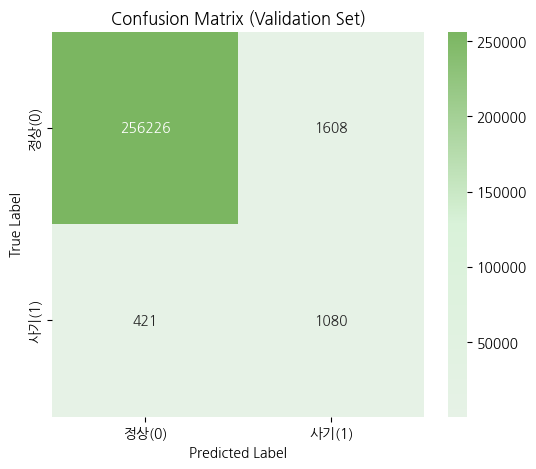


LightGBM 모델 평가 (테스트 데이터)

--- Test Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.369641  0.691375  0.481728  0.873078

Classification Report:
              precision    recall  f1-score   support

           0     0.9988    0.9954    0.9971    553574
           1     0.3696    0.6914    0.4817      2145

    accuracy                         0.9943    555719
   macro avg     0.6842    0.8434    0.7394    555719
weighted avg     0.9964    0.9943    0.9951    555719



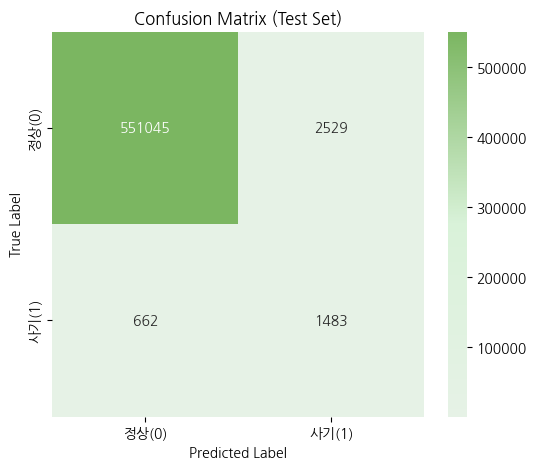

{'Precision': 0.36964107676969093,
 'Recall': 0.6913752913752914,
 'F1-Score': 0.48172811434140006,
 'ROC_AUC': np.float64(0.8730781442156976)}

In [19]:
# 검증 데이터 평가
print("\n" + "="*50)
print("LightGBM 모델 평가 (검증 데이터)")
evaluate_and_visualize(lgbm_clf, X_val_scaled, y_val_final, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
print("LightGBM 모델 평가 (테스트 데이터)")
evaluate_and_visualize(lgbm_clf, X_test_scaled, y_test_final, "Test Set")

In [20]:
xgb_clf = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False)
xgb_clf.fit(X_train_scaled, y_train_final)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)


XGBoost 모델 평가 (검증 데이터)

--- Validation Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.791281  0.798135  0.794693  0.972851

Classification Report:
              precision    recall  f1-score   support

           0     0.9988    0.9988    0.9988    257834
           1     0.7913    0.7981    0.7947      1501

    accuracy                         0.9976    259335
   macro avg     0.8951    0.8985    0.8967    259335
weighted avg     0.9976    0.9976    0.9976    259335



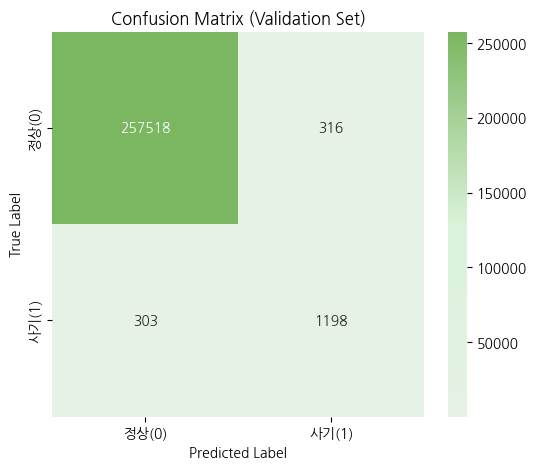


XGBoost 모델 평가 (테스트 데이터)

--- Test Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.668029  0.761772  0.711827  0.958269

Classification Report:
              precision    recall  f1-score   support

           0     0.9991    0.9985    0.9988    553574
           1     0.6680    0.7618    0.7118      2145

    accuracy                         0.9976    555719
   macro avg     0.8336    0.8802    0.8553    555719
weighted avg     0.9978    0.9976    0.9977    555719



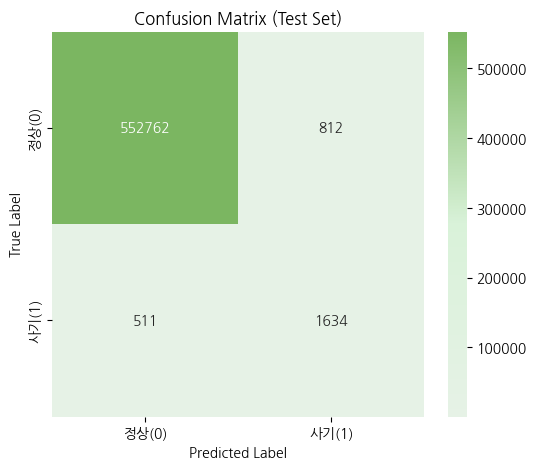

{'Precision': 0.6680294358135732,
 'Recall': 0.7617715617715618,
 'F1-Score': 0.7118274885645829,
 'ROC_AUC': np.float64(0.9582691627012712)}

In [21]:
# 검증 데이터 평가
print("\n" + "="*50)
print("XGBoost 모델 평가 (검증 데이터)")
evaluate_and_visualize(xgb_clf, X_val_scaled, y_val_final, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
print("XGBoost 모델 평가 (테스트 데이터)")
evaluate_and_visualize(xgb_clf, X_test_scaled, y_test_final, "Test Set")

In [22]:
cat_clf = CatBoostClassifier(random_state=42, verbose=0)
cat_clf.fit(X_train_scaled, y_train_final)


CatBoost 모델 평가 (검증 데이터)

--- Validation Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.876404  0.831446  0.853333  0.997225

Classification Report:
              precision    recall  f1-score   support

           0     0.9990    0.9993    0.9992    257834
           1     0.8764    0.8314    0.8533      1501

    accuracy                         0.9983    259335
   macro avg     0.9377    0.9154    0.9263    259335
weighted avg     0.9983    0.9983    0.9983    259335



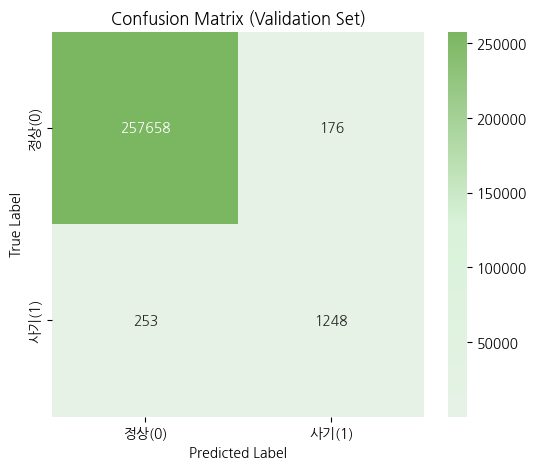


CatBoost 모델 평가 (테스트 데이터)

--- Test Set 평가 결과 ---
   Precision    Recall  F1-Score   ROC_AUC
0   0.830049  0.785548  0.807186  0.997335

Classification Report:
              precision    recall  f1-score   support

           0     0.9992    0.9994    0.9993    553574
           1     0.8300    0.7855    0.8072      2145

    accuracy                         0.9986    555719
   macro avg     0.9146    0.8925    0.9032    555719
weighted avg     0.9985    0.9986    0.9985    555719



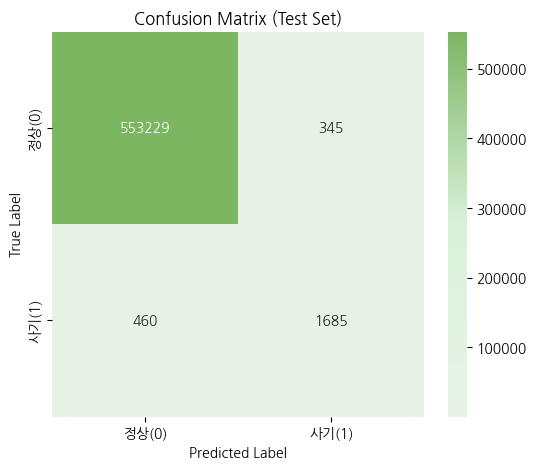

{'Precision': 0.8300492610837439,
 'Recall': 0.7855477855477856,
 'F1-Score': 0.807185628742515,
 'ROC_AUC': np.float64(0.9973350237936365)}

In [23]:
# 검증 데이터 평가
print("\n" + "="*50)
print("CatBoost 모델 평가 (검증 데이터)")
evaluate_and_visualize(cat_clf, X_val_scaled, y_val_final, "Validation Set")

# 테스트 데이터 평가
print("\n" + "="*50)
print("CatBoost 모델 평가 (테스트 데이터)")
evaluate_and_visualize(cat_clf, X_test_scaled, y_test_final, "Test Set")